# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [ ]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.1 MB/s eta 0:00:00


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [104]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
import time

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to split the data into train and test
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer

# Import MinMaxScaler for feature scaling.
from sklearn.preprocessing import StandardScaler

import tensorflow as tf #An end-to-end open source machine learning platform
from tensorflow import keras  # High-level neural networks API for deep learning.
from keras import backend   # Abstraction layer for neural network backend engines.
from keras.models import Sequential  # Model for building NN sequentially.
from keras.layers import Dense, Dropout, BatchNormalization, Input

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()

# **Loading the Data**

In [4]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# loading the dataset
data = pd.read_csv("/content/drive/MyDrive/Python Files/Train.csv")
data_test=pd.read_csv("/content/drive/MyDrive/Python Files/Test.csv")

# **Data Overview**

####**Displaying the first few rows of the dataset**

In [6]:
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,-5.714719,0.735893,0.981251,1.417884,-3.375815,-3.047303,0.306194,2.914097,2.269979,4.394876,-2.388299,0.646388,-1.190508,3.132986,0.665277,-2.510846,-0.036744,0.726218,-3.982187,-1.072638,1.667098,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,1.914465,-0.951458,-1.255259,-2.706522,0.193223,-4.769379,-2.205319,0.907716,0.756894,-5.833678,-3.065122,1.596647,-1.757311,1.766444,-0.267098,3.625036,1.500346,-0.585712,0.783034,-0.201217,0.024883,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,-0.770673,1.106718,1.144261,0.943301,-3.163804,-4.247825,-4.038909,3.688534,3.311196,1.059002,-2.143026,1.650120,-1.660592,1.679910,-0.450782,-4.550695,3.738779,1.134404,-2.033531,0.840839,-1.600395,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,-3.053023,0.459719,2.704527,-0.636086,-0.453717,-3.174046,-3.404347,-1.281536,1.582104,-1.951778,-3.516555,-1.206011,-5.627854,-1.817653,2.124142,5.294642,4.748137,-2.308536,-3.962977,-6.028730,4.948770,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,1.998347,4.723757,0.709113,-1.989432,-2.632684,4.184447,2.245356,3.734452,-6.312766,-5.379918,-0.886667,2.061694,9.445586,4.489976,-3.945144,4.582065,-8.780422,-3.382967,5.106507,6.787513,2.044184,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


####**Displaying the last few rows of the dataset**

In [7]:
data.tail()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
19995,-2.071318,-1.088279,-0.796174,-3.011720,-2.287540,2.807310,0.481428,0.105171,-0.586599,-2.899398,8.868415,1.717155,1.357838,-1.777135,0.709780,4.944939,-3.100454,-1.199228,-1.084629,-0.365044,3.131175,-3.948103,-3.578469,-8.139067,-1.936861,-1.327691,-0.402688,-1.734796,9.996461,6.955367,-3.938493,-8.273996,5.745013,0.589014,-0.649988,-3.043174,2.216461,0.608723,0.178193,2.927755,1
19996,2.890264,2.483069,5.643919,0.937053,-1.380870,0.412051,-1.593386,-5.762498,2.150096,0.272302,-2.094760,-1.525834,0.071573,-3.540142,-2.762006,-10.632206,-0.495236,1.720074,3.871596,-1.209610,-8.222073,2.120866,-5.491808,1.452340,1.450002,3.684654,1.076760,-0.384175,-0.838593,-0.748275,-1.088553,-4.159092,1.181466,-0.742412,5.368979,-0.693028,-1.668971,3.659954,0.819863,-1.987265,0
19997,-3.896979,-3.942407,-0.351364,-2.417462,1.107546,-1.527623,-3.519882,2.054792,-0.233996,-0.357687,-3.781972,2.180042,6.111780,1.984747,-8.330002,-1.639184,-0.914960,5.672348,-3.924200,2.133196,-4.502031,2.777178,5.727949,1.619818,-1.699691,-0.041882,-2.923094,-2.760158,-2.253766,2.552033,0.981858,7.112162,1.476080,-3.953710,1.855555,5.029209,2.082588,-6.409304,1.477138,-0.874148,0
19998,-3.187322,-10.051662,5.695955,-4.370053,-5.354758,-1.873044,-3.947210,0.679420,-2.389254,5.456756,1.583029,3.571478,9.226573,2.553587,-7.039109,-0.993573,-9.664938,1.155224,3.876895,3.523634,-7.015329,-0.132037,-3.446179,-4.801443,-0.875727,-3.811854,5.422077,-3.732322,0.608811,5.256460,1.914766,0.402812,3.163661,3.752095,8.529894,8.450626,0.203958,-7.129918,4.249394,-6.112267,0
19999,-2.686903,1.961187,6.137088,2.600133,2.657241,-4.290882,-2.344267,0.974004,-1.027462,0.497421,-9.589075,3.176560,1.054517,-1.415882,-4.668611,-5.405377,3.719759,2.892923,2.328591,1.457704,-6.428543,1.818232,0.805897,7.786026,0.330857,5.257424,-4.867417,-0.818941,-5.667393,-2.860975,4.674280,6.620811,-1.988786,-1.348901,3.951801,5.449706,-0.455411,-2.202056,1.678229,-1.974413,0


**Checking the shape of the dataset**

In [8]:
data.shape

(20000, 41)

The data consists of 20000 rows and 41 columns

####**Checking the data types of the columns of the dataset**

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

The data contains 20000 records with 41 features(float type).v1 and v2 columns have 18 missing values.

####**Checking for missing values**

In [10]:
data.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


We observe that there are 18 missing rows in v1 and v2 columns, and rest of the 39 columns have no missing values.


####**Checking statistical summary**

In [11]:
data.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,19982.000000,19982.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-0.271996,0.440430,2.484699,-0.083152,-0.053752,-0.995443,-0.879325,-0.548195,-0.016808,-0.012998,-1.895393,1.604825,1.580486,-0.950632,-2.414993,-2.925225,-0.134261,1.189347,1.181808,0.023608,-3.611252,0.951835,-0.366116,1.134389,-0.002186,1.873785,-0.612413,-0.883218,-0.985625,-0.015534,0.486842,0.303799,0.049825,-0.462702,2.229620,1.514809,0.011316,-0.344025,0.890653,-0.875630,0.055500
std,3.441625,3.150784,3.388963,3.431595,2.104801,2.040970,1.761626,3.295756,2.160568,2.193201,3.124322,2.930454,2.874658,1.789651,3.354974,4.221717,3.345462,2.592276,3.396925,3.669477,3.567690,1.651547,4.031860,3.912069,2.016740,3.435137,4.368847,1.917713,2.684365,3.005258,3.461384,5.500400,3.575285,3.183841,2.937102,3.800860,1.788165,3.948147,1.753054,3.012155,0.228959
min,-11.876451,-12.319951,-10.708139,-15.082052,-8.603361,-10.227147,-7.949681,-15.657561,-8.596313,-9.853957,-14.832058,-12.948007,-13.228247,-7.738593,-16.416606,-20.374158,-14.091184,-11.643994,-13.491784,-13.922659,-17.956231,-10.122095,-14.866128,-16.387147,-8.228266,-11.834271,-14.904939,-9.269489,-12.579469,-14.796047,-13.722760,-19.876502,-16.898353,-17.985094,-15.349803,-14.833178,-5.478350,-17.375002,-6.438880,-11.023935,0.000000
25%,-2.737146,-1.640674,0.206860,-2.347660,-1.535607,-2.347238,-2.030926,-2.642665,-1.494973,-1.411212,-3.922404,-0.396514,-0.223545,-2.170741,-4.415322,-5.634240,-2.215611,-0.403917,-1.050168,-2.432953,-5.930360,-0.118127,-3.098756,-1.468062,-1.365178,-0.337863,-3.652323,-2.171218,-2.787443,-1.867114,-1.817772,-3.420469,-2.242857,-2.136984,0.336191,-0.943809,-1.255819,-2.987638,-0.272250,-2.940193,0.000000
50%,-0.747917,0.471536,2.255786,-0.135241,-0.101952,-1.000515,-0.917179,-0.389085,-0.067597,0.100973,-1.921237,1.507841,1.637185,-0.957163,-2.382617,-2.682705,-0.014580,0.883398,1.279061,0.033415,-3.532888,0.974687,-0.262093,0.969048,0.025050,1.950531,-0.884894,-0.891073,-1.176181,0.184346,0.490304,0.052073,-0.066249,-0.255008,2.098633,1.566526,-0.128435,-0.316849,0.919261,-0.920806,0.000000
75%,1.840112,2.543967,4.566165,2.130615,1.340480,0.380330,0.223695,1.722965,1.409203,1.477045,0.118906,3.571454,3.459886,0.270677,-0.359052,-0.095046,2.068751,2.571770,3.493299,2.512372,-1.265884,2.025594,2.451750,3.545975,1.397112,4.130037,2.189177,0.375884,0.629773,2.036229,2.730688,3.761722,2.255134,1.436935,4.064358,3.983939,1.175533,2.279399,2.057540,1.119897,0.000000
max,15.493002,13.089269,17.090919,13.236381,8.133797,6.975847,8.006091,11.679495,8.137580,8.108472,11.826433,15.080698,15.419616,5.670664,12.246455,13.583212,16.756432,13.179863,13.237742,16.052339,13.840473,7.409856,14.458734,17.163291,8.223389,16.836410,17.560404,6.527643,10.722055,12.505812,17.255090,23.633187,16.692486,14.358213,15.291065,19.329576,7.467006,15.289923,7.759877,10.654265,1.000000


####**Checking for duplicate values**

In [12]:
# Check for duplicate rows
duplicate_rows = data[data.duplicated()]

# Print the number of duplicate rows
print(f"Number of duplicate rows: {len(duplicate_rows)}")

Number of duplicate rows: 0


There are no duplicate records in the data.

In [13]:
data['Target'].value_counts()

,count
Target,
0,18890
1,1110


In [14]:
data['Target'].value_counts(normalize=True)

,proportion
Target,
0,0.9445
1,0.0555


The dataset shows a severe imbalance, with 18890 no-failure machines (94.45%) and only 1110 failure machines(5.55%). This high imbalance will likely require special handling for model training.

# **Exploratory Data Analysis**

In [15]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [16]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
def labeled_boxplot(df, x_col, y_col, title, x_label, y_label):
    """Generates a box plot with customizable data and labels."""

    # Simple check for necessary columns
    if x_col not in df.columns or y_col not in df.columns:
        print(f"Error: Columns '{x_col}' or '{y_col}' not found in the DataFrame.")
        return

    plt.figure(figsize=(8, 6))

    sns.boxplot(
        x=x_col,
        y=y_col,
        data=df
    )

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()

In [ ]:
def filtered_countplot(df, filter_col, filter_val, count_col, title, x_label, y_label):
    """
    Filters a DataFrame and creates a count plot (bar chart) for a specified column.

    Parameters:
    df (pd.DataFrame): The input DataFrame.
    filter_col (str): The column used to filter the data (e.g., 'fraud').
    filter_val (int/str): The value used for filtering (e.g., 1).
    count_col (str): The column to be counted and plotted on the x-axis (e.g., 'online_order').
    title (str): The title of the plot.
    x_label (str): The label for the x-axis.
    y_label (str): The label for the y-axis.
    """

    # Check for required columns
    required_cols = [filter_col, count_col]
    if not all(col in df.columns for col in required_cols):
        print(f"Error: DataFrame is missing one or more required columns: {required_cols}")
        return

    # Filter the DataFrame
    filtered_df = df[df[filter_col] == filter_val]

    # Create the bar chart (countplot)
    plt.figure(figsize=(8, 6))
    sns.countplot(x=count_col, data=filtered_df)

    # Set labels and title
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    plt.show()

In [6]:
df1 = data.copy()

## Univariate analysis

###Target Distribution

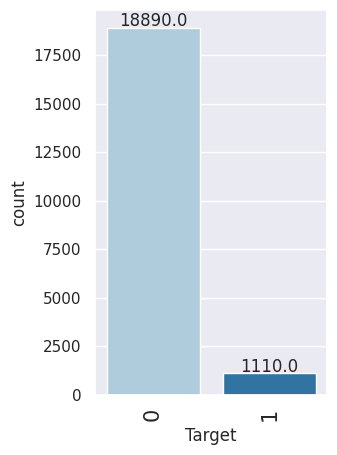

In [19]:
labeled_barplot(df1, 'Target')

Out of 20000 machines only 1110 machines are identified as failed machines.

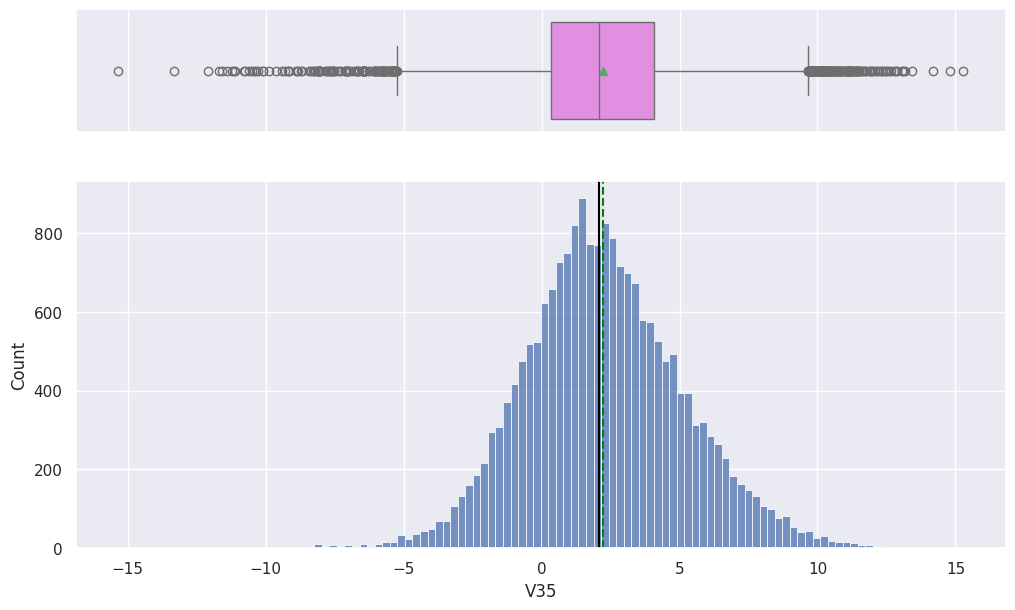

In [ ]:
histogram_boxplot(df1, 'V16')

The distribution of v16 appears approximately normal with moderate spread around the center.The mean and median are relatively close,indicating limited skewness.

## Bivariate Analysis

###Correlation Check

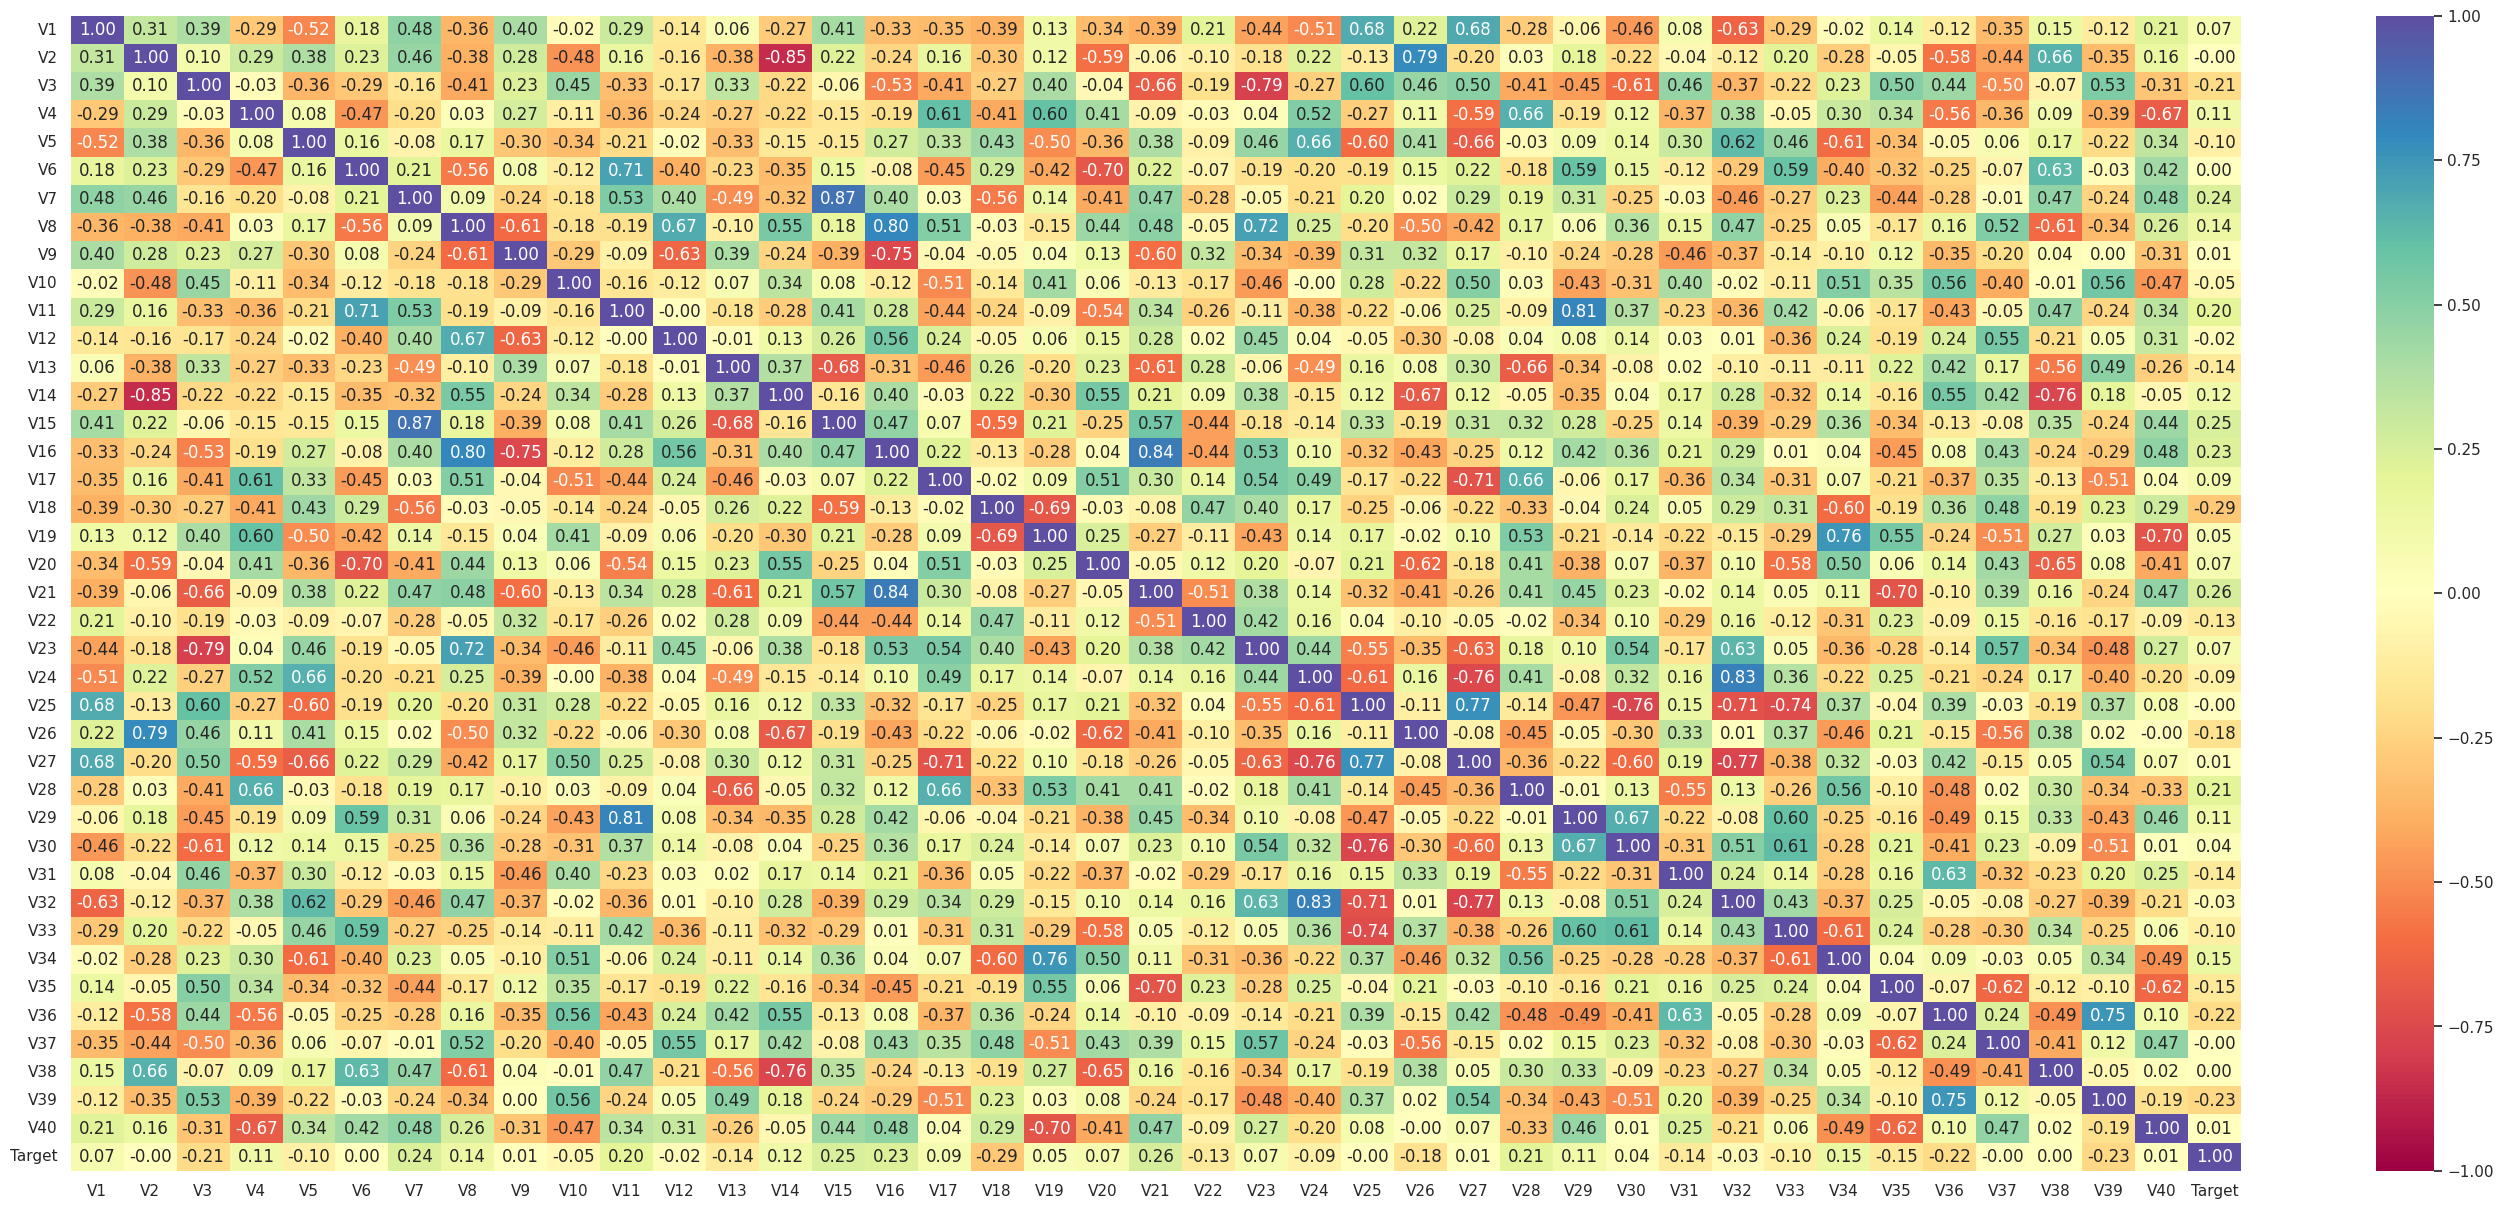

In [ ]:
plt.figure(figsize=(35, 15))
sns.heatmap(
    df1.corr(numeric_only = True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()



*   Most features show low to moderate correlation with each other.
*   A few feature pairs have high positive or negative correlation.



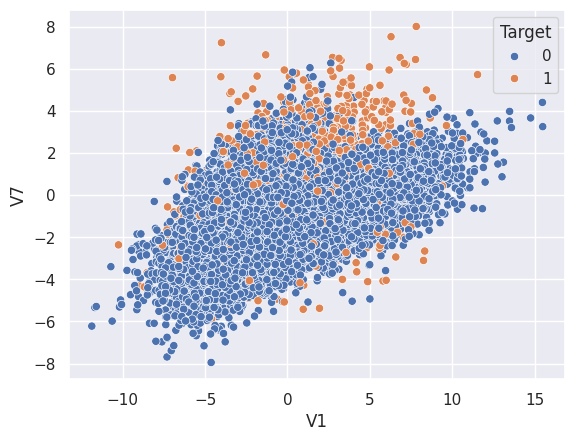

In [ ]:
sns.scatterplot(x='V1', y='V7', data=df1, hue='Target')
plt.show();

The scatterplot between V1 and V7 shows a positive relationship between the two variables,confirming the correlation observed in the heatmap

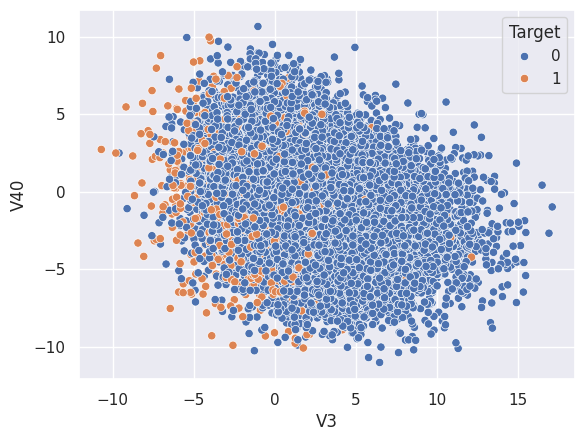

In [ ]:
sns.scatterplot(x='V3', y='V40', data=df1, hue='Target')
plt.show();

The scatterplot between V3 and V40 indicates a negative relationship between the two variables.

###Target vs V16

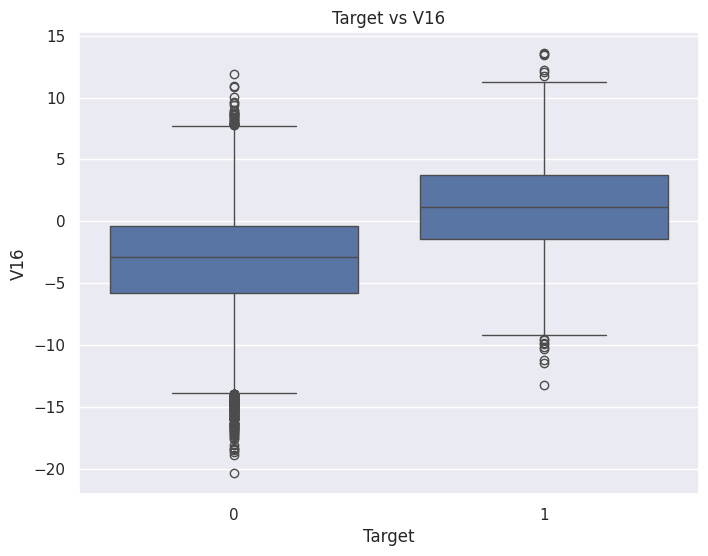

In [ ]:
labeled_boxplot(df1, 'Target', 'V16', 'Target vs V16', 'Target', 'V16')

No failure machine has lower median compared to failure machines.

###Target vs V17

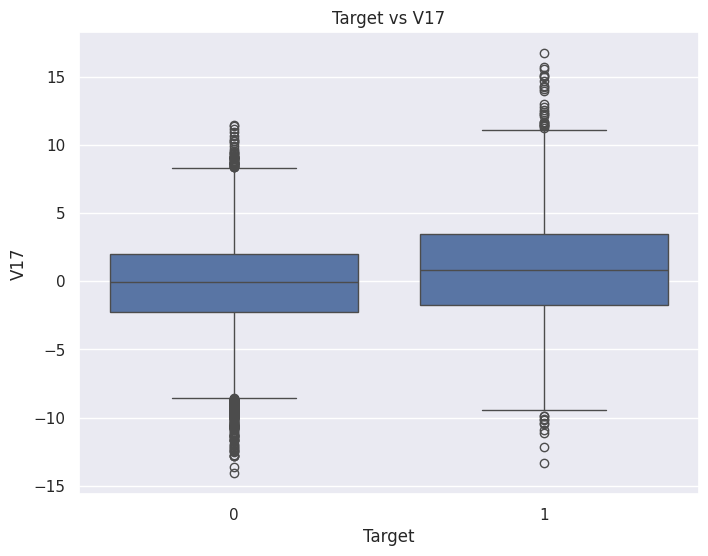

In [ ]:
labeled_boxplot(df1, 'Target', 'V17', 'Target vs V17', 'Target', 'V17')

# **Data Preprocessing**

In [7]:
# Split data into training, validation sets (80:20)
X=df1.drop('Target',axis=1)
y=df1['Target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [8]:
# Dividing test data into X_test and y_test
X_test=data_test.drop('Target',axis=1)
y_test=data_test['Target']

####Missing value treatment


There are 18 missing values in V1 and V2 columns in dataset.So we are going impute them using the median value.

In [9]:
imputer = SimpleImputer(strategy="median")

In [10]:
# Get column names from the original X DataFrame (before scaling)
# X is available in kernel state and is a DataFrame with original column names
feature_columns = X.columns

# Fit and transform the train data
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_columns)

# Transform the validation data
X_val = pd.DataFrame(imputer.transform(X_val), columns=feature_columns)

# Transform the test data
X_test = pd.DataFrame(imputer.transform(X_test), columns=feature_columns)

In [11]:
# Checking that no column has missing values in train or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22

In [12]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16000, 40)
X_val shape: (4000, 40)
y_train shape: (16000,)
y_val shape: (4000,)
X_test shape: (5000, 40)
y_test shape: (5000,)


In [12]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_val=scaler.transform(X_val)
X_test=scaler.transform(X_test)

###**Model Building**

With the data prepared, we now move to building and training Artificial Neural Networks (ANNs) to predict fraud. We'll experiment with different ANN architectures to find the most effective setup.

What We’ll Do:

Define the ANN model – Try out various architectures.
Train the model – Use training data to learn patterns.
Validate and test – Evaluate the model on unseen data.

## Model Evaluation Criterion



*   False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
*   False positives (FP) are detections where there is no failure. These will result in inspection costs.

In this case, replacement costs will be higher compared to inspection cost.

Company would want Recall to be maximized, greater the Recall higher the chances of minimizing false Negative. Hence, the focus should be on increasing Recall or minimizing the false Negative






## Initial Model Building (Model 0)

- Let's start with a neural network consisting of
  - just one hidden layer
  - activation function of ReLU
  - SGD as the optimizer

####Utility functions

In [13]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

We'll create a dataframe to store the results from all the models we build

In [14]:
# Create a blank DataFrame to store the training and validation evaluation results of different models.

evaluation_results = pd.DataFrame(columns=['Model', '# hidden layers', '# neurons hidden layer', 'activation function hidden layer', 'configuration', '# epochs', 'batch size', 'Train_Loss', 'Train_Accuracy', 'Train_Precision', 'Train_Recall', 'Train_F1',
                                         'Val_Loss', 'Val_Accuracy', 'Val_Precision', 'Val_Recall', 'Val_F1'])

###Model 0

We build this baseline neural network model using a simple architecture:

**Input Layer:** The input shape is determined by the number of features in the

*   **Input Layer:** The input shape is determined by the number of features in the training data, X_train​.
*   **Hidden Layers:** We use one hidden layer, with 14 neurons, with ReLU activation function.
*   **Output Layer:** One Dense layer with 1 unit and a sigmoid activation to handle binary classification.

**Loss Function**:We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

**Optimizer**: We use Stochastic Gradient Descent (SGD) as the optimizer to adjust the network's weights during training.

**Metrics**: The model is evaluated using the Recall metric.

In [15]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [16]:
#Initializing the neural network
model0 = Sequential()

model0.add(Dense(14, activation='relu', input_shape=(X_train.shape[1],))) # Hidden Layer 1
model0.add(Dense(1, activation='sigmoid'))

In [17]:
#Printing the summary
model0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 589 (2.30 KB)

 Trainable params: 589 (2.30 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
optimizer = 'sgd'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'   # defining binary crossentropy as the loss function

#Compiling the model.
model0.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [19]:
epochs = 50   # training the model for 25 epochs
batch_size = 64    # setting the batch size equal to the number of rows

# time.time() returns the time in seconds since Thu Jan 1 00:00:00 1970.
start = time.time()

# Fitting the model.
history0 = model0.fit(X_train, y_train,
                      validation_data=(X_val,y_val) ,
                      batch_size=batch_size,
                      epochs=epochs)

# time.time() returns the time in seconds since Thu Jan 1 00:00:00 1970.
end = time.time()

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8819 - loss: 0.3677 - precision: 0.0783 - recall: 0.1047 - val_binary_accuracy: 0.9480 - val_loss: 0.2322 - val_precision: 0.8889 - val_recall: 0.0721
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9496 - loss: 0.1958 - precision: 0.8649 - recall: 0.1081 - val_binary_accuracy: 0.9542 - val_loss: 0.1744 - val_precision: 1.0000 - val_recall: 0.1757
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9567 - loss: 0.1597 - precision: 0.9079 - recall: 0.2444 - val_binary_accuracy: 0.9590 - val_loss: 0.1499 - val_precision: 1.0000 - val_recall: 0.2613
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9614 - loss: 0.1421 - precision: 0.9248 - recall: 0.3322 - val_binary_accuracy: 0.9632 - val_loss: 0.1354 - val_precision: 0.9870 - val_recall: 0.3423
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9636 - loss: 0.1313 - precision

In [20]:
print("Time taken in seconds ",end-start)

Time taken in seconds  38.813340187072754


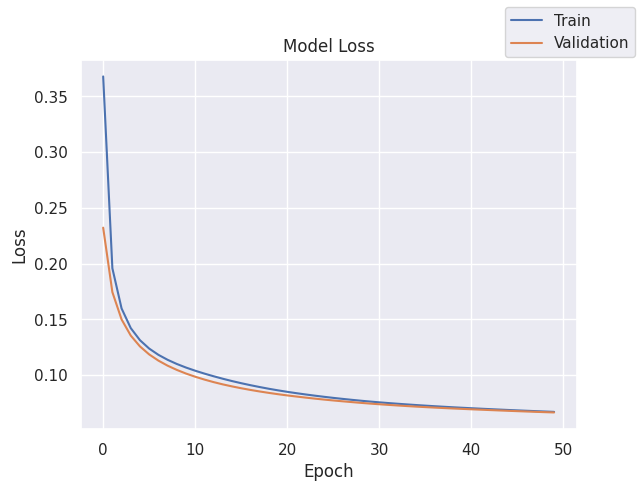

In [21]:
plot(history0,'loss')

In [23]:
evaluation_results.loc[0] = ['Model 0', '1', '[14]', 'ReLU', 'baseline', epochs, batch_size, history0.history["loss"][-1], history0.history["binary_accuracy"][-1], history0.history["precision"][-1], history0.history["recall"][-1], 2 * (history0.history["precision"][-1] * history0.history["recall"][-1]) / (history0.history["precision"][-1] + history0.history["recall"][-1] + 1e-7), history0.history["val_loss"][-1], history0.history["val_binary_accuracy"][-1], history0.history["val_precision"][-1], history0.history["val_recall"][-1], 2 * (history0.history["val_precision"][-1] * history0.history["val_recall"][-1]) / (history0.history["val_precision"][-1] + history0.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[14],ReLU,baseline,50,64,0.067027,0.985187,0.973799,0.753378,0.849524,0.066507,0.98475,0.976331,0.743243,0.84399



*   The model shows high accuracy and precision and the recall score of 74% indicate that the model is able to identify a significant portion of actual failures,although some failures are still missed.

*   The loss in the training and validation set decreases smoothly,and both the curves are very close.



# **Model Performance Improvement**

## Model 1

We built our **second **neural network model with the following changes:


*   First hidden layer now has 28 neurons, up from 14.
*   Second and third hidden layer added and has 14 neurons.  
*   We use a momentum of 0.9 for the optimizer
*   The model is trained for 50 epochs using a mini-batch gradient descent approach with a batch size of 64.

**Loss Function**:  We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

**Optimizer**: We use Stochastic Gradient Descent (SGD) as the optimizer to adjust the network's weights during training.

**Metrics**: The model is evaluated using the Recall metric.



In [24]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [25]:
#Initializing the neural network
model1 = Sequential()

model1.add(Dense(28, activation='relu', input_shape=(X_train.shape[1],)))
model1.add(Dense(14, activation='relu'))
model1.add(Dense(14, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

In [26]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 28)             │         1,148 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,779 (6.95 KB)

 Trainable params: 1,779 (6.95 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
optimizer = tf.keras.optimizers.SGD(momentum=0.9)   # Adding momentum to accelerate learning
loss = 'binary_crossentropy'  # defining binary crossentropy as the loss function

model1.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [28]:
epochs = 50
batch_size = 64

start = time.time()
history1 = model1.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.9370 - loss: 0.1880 - precision: 0.3592 - recall: 0.1723 - val_binary_accuracy: 0.9728 - val_loss: 0.1112 - val_precision: 0.8645 - val_recall: 0.6036
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9756 - loss: 0.0923 - precision: 0.9307 - recall: 0.6047 - val_binary_accuracy: 0.9785 - val_loss: 0.0826 - val_precision: 0.9000 - val_recall: 0.6892
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9818 - loss: 0.0730 - precision: 0.9529 - recall: 0.7061 - val_binary_accuracy: 0.9850 - val_loss: 0.0682 - val_precision: 0.9551 - val_recall: 0.7658
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9859 - loss: 0.0630 - precision: 0.9702 - recall: 0.7691 - val_binary_accuracy: 0.9893 - val_loss: 0.0613 - val_precision: 0.9543 - val_recall: 0.8468
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9880 - loss: 0.0568 - precision

In [29]:
print("Time taken in seconds ",end-start)

Time taken in seconds  39.96132135391235


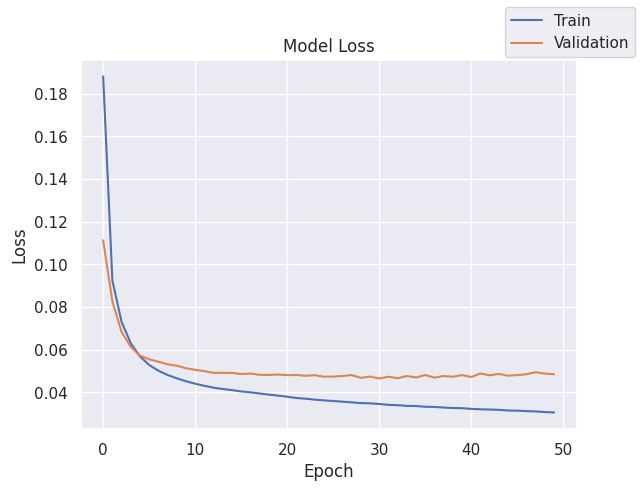

In [30]:
plot(history1,'loss')

In [31]:
evaluation_results.loc[1] = ['Model 1', '3', '[28, 14,14]', 'ReLU', 'momentum=0.9', epochs, batch_size, history1.history["loss"][-1], history1.history["binary_accuracy"][-1], history1.history["precision"][-1], history1.history["recall"][-1], 2 * (history1.history["precision"][-1] * history1.history["recall"][-1]) / (history1.history["precision"][-1] + history1.history["recall"][-1] + 1e-7), history1.history["val_loss"][-1], history1.history["val_binary_accuracy"][-1], history1.history["val_precision"][-1], history1.history["val_recall"][-1], 2 * (history1.history["val_precision"][-1] * history1.history["val_recall"][-1]) / (history1.history["val_precision"][-1] + history1.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[14],ReLU,baseline,50,64,0.067027,0.985187,0.973799,0.753378,0.849524,0.066507,0.98475,0.976331,0.743243,0.843990
1,Model 1,3,"[28, 14,14]",ReLU,momentum=0.9,50,64,0.030518,0.993875,0.988861,0.899775,0.942217,0.048436,0.99150,0.943396,0.900901,0.921659



*   Adding more hidden layers and momentum helped to improve the recall value(.90%).Now the model identify  larger portion of the minority (positive) cases.
*   The loss has reduced significantly on both training and validation data set.But there is a gap between training and validation loss
*   This model shows high accuracy,Precision and better recall. This strongly suggests model is able to identify the minority class effectively while mainitaining overall strong classification performance.



## Model 2

We built our **Third** neural network model with the following changes:


* First hidden layer now has 28 neurons, up from 14.
* Second and third hidden layer added and has 14 neurons.
* Added a dropout of 0.2 to each hidden layer
* We use a momentum of 0.9 for the optimizer


The model is trained for 50 epochs using a mini-batch gradient descent approach with a batch size of 64.

**Loss Function**: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

**Optimizer**: We use Stochastic Gradient Descent (SGD) as the optimizer to adjust the network's weights during training.

**Metrics**: The model is evaluated using the Recall metric.


  



In [32]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [33]:
#Initializing the neural network
model2 = Sequential()
model2.add(Dense(28, activation='relu', input_shape=(X_train.shape[1],)))
model2.add(Dropout(0.2)) # Dropout layer to prevent overfitting
model2.add(Dense(14, activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(14, activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(1, activation='sigmoid'))

In [34]:
optimizer = tf.keras.optimizers.SGD(momentum=0.9)   # Adding momentum to accelerate learning
loss = 'binary_crossentropy'  # defining binary crossentropy as the loss function

model2.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [35]:
epochs = 50
batch_size = 64

start = time.time()
history2 = model2.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - binary_accuracy: 0.9441 - loss: 0.1832 - precision: 0.4690 - recall: 0.0597 - val_binary_accuracy: 0.9640 - val_loss: 0.1262 - val_precision: 0.9756 - val_recall: 0.3604
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9604 - loss: 0.1309 - precision: 0.7913 - recall: 0.3885 - val_binary_accuracy: 0.9765 - val_loss: 0.0926 - val_precision: 0.9706 - val_recall: 0.5946
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9672 - loss: 0.1125 - precision: 0.8396 - recall: 0.5068 - val_binary_accuracy: 0.9822 - val_loss: 0.0773 - val_precision: 0.9689 - val_recall: 0.7027
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9731 - loss: 0.0985 - precision: 0.8855 - recall: 0.5923 - val_binary_accuracy: 0.9862 - val_loss: 0.0664 - val_precision: 0.9771 - val_recall: 0.7703
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9779 - loss: 0.0873 - precision

In [36]:
print("Time taken in seconds ",end-start)

Time taken in seconds  44.89360284805298


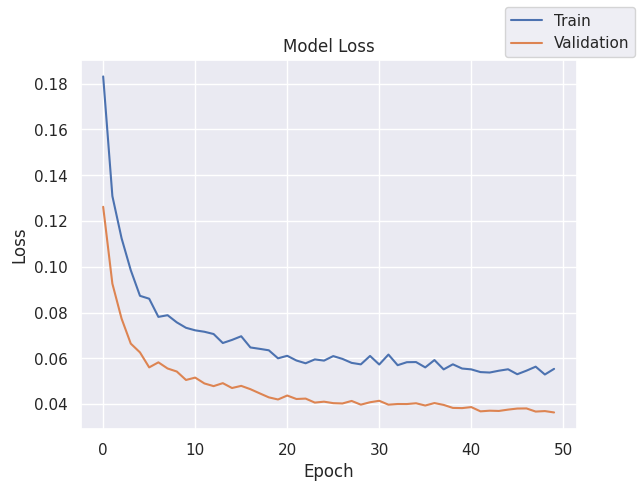

In [37]:
plot(history2,'loss')

In [38]:
evaluation_results.loc[2] = ['Model 2', '3', '[28, 14, 14]', 'ReLU', 'momentum=0.9,Dropout(0.2)', epochs, batch_size, history2.history["loss"][-1], history2.history["binary_accuracy"][-1], history2.history["precision"][-1], history2.history["recall"][-1], 2 * (history2.history["precision"][-1] * history2.history["recall"][-1]) / (history2.history["precision"][-1] + history2.history["recall"][-1] + 1e-7), history2.history["val_loss"][-1], history2.history["val_binary_accuracy"][-1], history2.history["val_precision"][-1], history2.history["val_recall"][-1], 2 * (history2.history["val_precision"][-1] * history2.history["val_recall"][-1]) / (history2.history["val_precision"][-1] + history2.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[14],ReLU,baseline,50,64,0.067027,0.985187,0.973799,0.753378,0.849524,0.066507,0.98475,0.976331,0.743243,0.843990
1,Model 1,3,"[28, 14,14]",ReLU,momentum=0.9,50,64,0.030518,0.993875,0.988861,0.899775,0.942217,0.048436,0.99150,0.943396,0.900901,0.921659
2,Model 2,3,"[28, 14, 14]",ReLU,"momentum=0.9,Dropout(0.2)",50,64,0.055385,0.988625,0.969415,0.820946,0.889024,0.036342,0.99350,0.971154,0.909910,0.939535


Adding dropout regularization helped reduce overfitting and improved the model's ability to generalize on unseen validation data.

Although the training recall decreased,the validation recall improved to ~ 91%,indicating better detection of failure cases.

Model 2 achieved one of the lowest validation losses among all models while maintaining strong recall performance,making it a more balanced and generalized model.

## Model 3

We built our **fourth** neural network model with the following changes:

* Added a dropout of 0.2 to each hidden layer

*  Use of Adam as the optimizer to   automatically adjust the learning rate  


**Loss Function**: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

**Optimizer**: We use Adam as the optimizer for this model.

**Metrics**: The model is evaluated using the Recall metric.

In [39]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [40]:
#Initializing the neural network
model3 = Sequential()
model3.add(Dense(28, activation='relu', input_shape=(X_train.shape[1],)))
model3.add(Dropout(0.2)) # Dropout layer to prevent overfitting
model3.add(Dense(14, activation='relu'))
model3.add(Dropout(0.2))
model3.add(Dense(14, activation='relu'))
model3.add(Dropout(0.2))
model3.add(Dense(1, activation='sigmoid'))

In [41]:
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 28)             │         1,148 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,779 (6.95 KB)

 Trainable params: 1,779 (6.95 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
optimizer = 'adam'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model3.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [43]:
epochs = 50
batch_size = 64

start = time.time()
history3 = model3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.8793 - loss: 0.3366 - precision: 0.0539 - recall: 0.0709 - val_binary_accuracy: 0.9445 - val_loss: 0.1472 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9489 - loss: 0.1515 - precision: 0.8737 - recall: 0.0935 - val_binary_accuracy: 0.9653 - val_loss: 0.1160 - val_precision: 0.9882 - val_recall: 0.3784
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9666 - loss: 0.1237 - precision: 0.8481 - recall: 0.4842 - val_binary_accuracy: 0.9827 - val_loss: 0.0870 - val_precision: 0.9752 - val_recall: 0.7072
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9753 - loss: 0.1051 - precision: 0.8894 - recall: 0.6340 - val_binary_accuracy: 0.9868 - val_loss: 0.0742 - val_precision: 0.9669 - val_recall: 0.7883
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.9808 - loss: 0.0909 - p

In [44]:
print("Time taken in seconds ",end-start)

Time taken in seconds  52.162816524505615


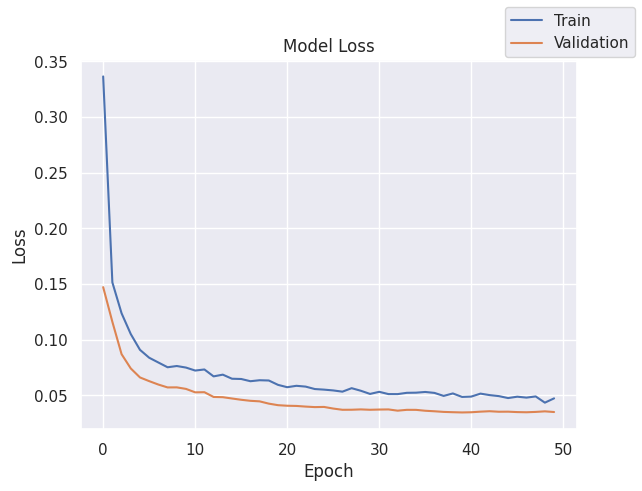

In [45]:
plot(history3,'loss')

In [99]:
evaluation_results.loc[3] = ['Model 3', '3', '[28, 14, 14]', 'ReLU', 'optimizer=adam,momentum=0.9,Dropout(0.2)', epochs, batch_size, history3.history["loss"][-1], history3.history["binary_accuracy"][-1], history3.history["precision"][-1], history3.history["recall"][-1], 2 * (history3.history["precision"][-1] * history3.history["recall"][-1]) / (history3.history["precision"][-1] + history3.history["recall"][-1] + 1e-7), history3.history["val_loss"][-1], history3.history["val_binary_accuracy"][-1], history3.history["val_precision"][-1], history3.history["val_recall"][-1], 2 * (history3.history["val_precision"][-1] * history3.history["val_recall"][-1]) / (history3.history["val_precision"][-1] + history3.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[14],ReLU,baseline,50,64,0.067027,0.985187,0.973799,0.753378,0.849524,0.066507,0.98475,0.976331,0.743243,0.843990
1,Model 1,3,"[28, 14,14]",ReLU,momentum=0.9,50,64,0.030518,0.993875,0.988861,0.899775,0.942217,0.048436,0.99150,0.943396,0.900901,0.921659
2,Model 2,3,"[28, 14, 14]",ReLU,"momentum=0.9,Dropout(0.2)",50,64,0.055385,0.988625,0.969415,0.820946,0.889024,0.036342,0.99350,0.971154,0.909910,0.939535
3,Model 3,3,"[28, 14, 14]",ReLU,"optimizer=adam,momentum=0.9,Dropout(0.2)",50,64,0.047309,0.991562,0.977186,0.868243,0.919499,0.035026,0.99375,0.975845,0.909910,0.941725
4,Model 4,2,"[28, 14,14]",ReLU,"BatchNormalization(),Dropout(0.2),momentum=0.9",50,64,0.062774,0.984750,0.937500,0.777027,0.849754,0.040826,0.99175,0.994764,0.855856,0.920097
5,Model 5,2,"[28, 14]",ReLU,"Class Weights,momentum=0.9,Dropout(0.2)",50,64,0.184231,0.981250,0.792829,0.896396,0.841438,0.122841,0.98650,0.850000,0.918919,0.883117
6,Model 6,2,"[28, 14]",ReLU,"Class Weights,Optimizer=Adam,Dropout(0.1)",50,64,0.150481,0.985000,0.830612,0.916667,0.871520,0.100000,0.98825,0.878788,0.914414,0.896247


*   The training and validation loss curves decreases steadily and remain close to eachother throughout training,similar to Model 2.
*   The validation recall remains ~ 91% showing that the model is able to correctly identify most failure cases.However compared to Model 2,the accuracy and F1 score are slightly higher.This suggests that replacing SGD with Adam did not provide additional improvement for this dataset,and Model 2 still remains the better-performing model.



## Model 4

We built our **fifth** neural network model with the following changes

*   It uses Batch Normalization and dropout(0.2) after each of the first three dense layers to help stabilize learning.

**Loss Function**: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

**Optimizer**: We use SGD as the optimizer with the mometum of 0.9 for this model.

**Metrics**: The model is evaluated using the Recall metric.



In [47]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [48]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [70]:
#Initializing the neural network
model4 = Sequential()
model4.add(Dense(28, activation='relu', input_shape=(X_train.shape[1],)))
model4.add(BatchNormalization()) # Stabilizes learning
model4.add(Dropout(0.2)) # Dropout layer to prevent overfitting
model4.add(Dense(14, activation='relu'))
model4.add(BatchNormalization()) # Stabilizes learning
model4.add(Dropout(0.2))
model3.add(Dense(14, activation='relu'))
model4.add(BatchNormalization()) # Stabilizes learning
model4.add(Dropout(0.2))
model4.add(Dense(1, activation='sigmoid'))

In [71]:
model4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 28)             │         1,148 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28)             │           112 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14)             │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 14)             │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,793 (7.00 KB)

 Trainable params: 1,681 (6.57 KB)

 Non-trainable params: 112 (448.00 B)

In [72]:
optimizer = tf.keras.optimizers.SGD(momentum=0.9)   # Adding momentum to accelerate learning
loss = 'binary_crossentropy'  # defining binary crossentropy as the loss function

model4.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [73]:
epochs = 50
batch_size = 64

start = time.time()
history4 = model4.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - binary_accuracy: 0.9324 - loss: 0.2001 - precision_3: 0.3895 - recall_3: 0.3851 - val_binary_accuracy: 0.9703 - val_loss: 0.0922 - val_precision_3: 0.9725 - val_recall_3: 0.4775
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9644 - loss: 0.1141 - precision_3: 0.7912 - recall_3: 0.4865 - val_binary_accuracy: 0.9760 - val_loss: 0.0739 - val_precision_3: 0.9773 - val_recall_3: 0.5811
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9691 - loss: 0.1002 - precision_3: 0.8339 - recall_3: 0.5541 - val_binary_accuracy: 0.9830 - val_loss: 0.0621 - val_precision_3: 0.9812 - val_recall_3: 0.7072
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.9750 - loss: 0.0900 - precision_3: 0.8777 - recall_3: 0.6385 - val_binary_accuracy: 0.9852 - val_loss: 0.0585 - val_precision_3: 0.9822 - val_recall_3: 0.7477
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0

In [74]:
print("Time taken in seconds ",end-start)

Time taken in seconds  52.49029612541199


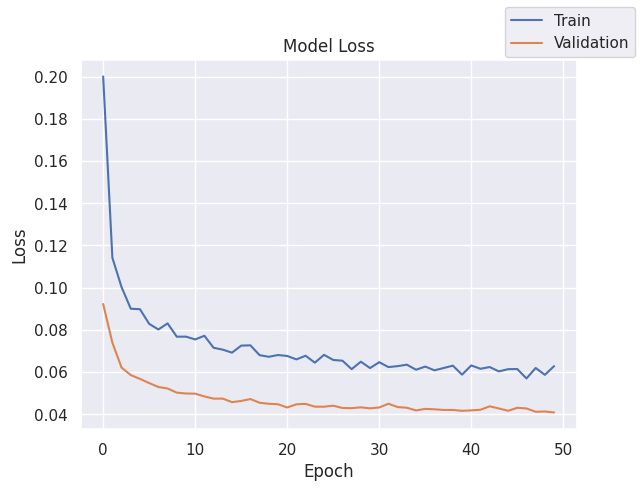

In [75]:
plot(history4,'loss')

In [122]:
evaluation_results.loc[4] = ['Model 4', '3', '[28, 14,14]', 'ReLU', 'BatchNormalization(),momentum=0.9 ,Dropout(0.2)', epochs, batch_size, history4.history["loss"][-1], history4.history["binary_accuracy"][-1], history4.history["precision_3"][-1], history4.history["recall_3"][-1], 2 * (history4.history["precision_3"][-1] * history4.history["recall_3"][-1]) / (history4.history["precision_3"][-1] + history4.history["recall_3"][-1] + 1e-7), history4.history["val_loss"][-1], history4.history["val_binary_accuracy"][-1], history4.history["val_precision_3"][-1], history4.history["val_recall_3"][-1], 2 * (history4.history["val_precision_3"][-1] * history4.history["val_recall_3"][-1]) / (history4.history["val_precision_3"][-1] + history4.history["val_recall_3"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[14],ReLU,baseline,50,64,0.067027,0.985187,0.973799,0.753378,0.849524,0.066507,0.98475,0.976331,0.743243,0.843990
1,Model 1,3,"[28, 14,14]",ReLU,momentum=0.9,50,64,0.030518,0.993875,0.988861,0.899775,0.942217,0.048436,0.99150,0.943396,0.900901,0.921659
2,Model 2,3,"[28, 14, 14]",ReLU,"momentum=0.9,Dropout(0.2)",50,64,0.055385,0.988625,0.969415,0.820946,0.889024,0.036342,0.99350,0.971154,0.909910,0.939535
3,Model 3,3,"[28, 14, 14]",ReLU,"optimizer=adam,momentum=0.9,Dropout(0.2)",50,64,0.047309,0.991562,0.977186,0.868243,0.919499,0.035026,0.99375,0.975845,0.909910,0.941725
4,Model 4,3,"[28, 14,14]",ReLU,"BatchNormalization(),momentum=0.9 ,Dropout(0.2)",50,64,0.062774,0.984750,0.937500,0.777027,0.849754,0.040826,0.99175,0.994764,0.855856,0.920097
5,Model 5,2,"[28, 14,14]",ReLU,"Class Weights,momentum=0.9,Dropout(0.2)",50,64,0.184231,0.981250,0.792829,0.896396,0.841438,0.122841,0.98650,0.850000,0.918919,0.883117
6,Model 6,3,"[28, 14, 14]",ReLU,"Class Weights,Optimizer=Adam,Dropout(0.1)",50,64,0.164196,0.978188,0.749768,0.911036,0.822572,0.113254,0.98450,0.822581,0.918919,0.868085


Training and validation losses slightly increased due to Batch Normalization.While the learning process remained stable.

Recall value significatnly reduced in this model,indicating poorer identification of failure cases.Hence batch normalization did not improve performance for this dataset.

## Model 5

We built our **sixth** neural network model with the following changes

*   It uses Class weights to handle class imbalance in this dataset.
  

**Loss Function**: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

**Optimizer**: We use SGD as the optimizer with the mometum of 0.9 for this model.

**Metrics**: The model is evaluated using the Recall metric.

In [78]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(class_weight = "balanced",classes = np.unique(y_train), y = y_train)
class_weights = dict(enumerate(class_weights))
class_weights

{0: np.float64(0.5293806246691372), 1: np.float64(9.00900900900901)}

In [79]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [80]:
#Initializing the neural network
model5 = Sequential()
model5.add(Dense(28, activation='relu', input_shape=(X_train.shape[1],)))
model5.add(Dropout(0.2)) # Dropout layer to prevent overfitting
model5.add(Dense(14, activation='relu'))
model5.add(Dropout(0.2))
model5.add(Dense(14, activation='relu'))
model5.add(Dropout(0.2))
model5.add(Dense(1, activation='sigmoid'))

In [81]:
model5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 28)             │         1,148 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,779 (6.95 KB)

 Trainable params: 1,779 (6.95 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
optimizer = tf.keras.optimizers.SGD(momentum=0.9)   # Adding momentum to accelerate learning
loss = 'binary_crossentropy'  # defining binary crossentropy as the loss function

model5.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [83]:
epochs = 50
batch_size = 64

start = time.time()
history5 = model5.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=class_weights)
end = time.time()

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - binary_accuracy: 0.8011 - loss: 0.4557 - precision: 0.1881 - recall: 0.7793 - val_binary_accuracy: 0.9018 - val_loss: 0.3300 - val_precision: 0.3528 - val_recall: 0.9234
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9205 - loss: 0.3194 - precision: 0.3972 - recall: 0.8356 - val_binary_accuracy: 0.9268 - val_loss: 0.2503 - val_precision: 0.4253 - val_recall: 0.9099
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9471 - loss: 0.2774 - precision: 0.5140 - recall: 0.8502 - val_binary_accuracy: 0.9240 - val_loss: 0.2825 - val_precision: 0.4156 - val_recall: 0.9099
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9553 - loss: 0.2612 - precision: 0.5638 - recall: 0.8559 - val_binary_accuracy: 0.9475 - val_loss: 0.2136 - val_precision: 0.5152 - val_recall: 0.9144
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9628 - loss: 0.2436 - precision

In [84]:
print("Time taken in seconds ",end-start)

Time taken in seconds  47.39958095550537


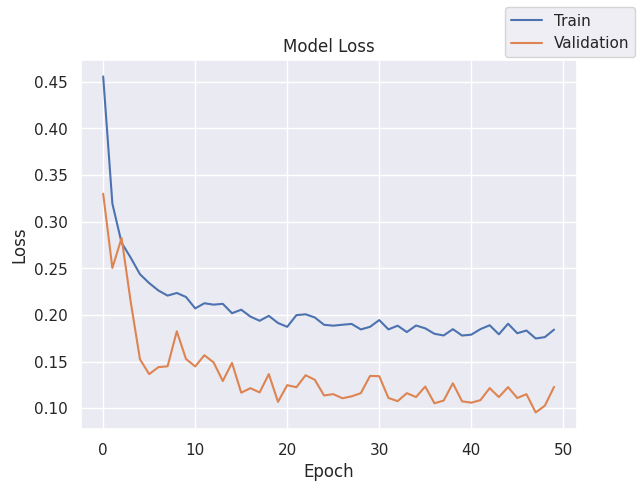

In [85]:
plot(history5,'loss')

In [123]:
evaluation_results.loc[5] = ['Model 5', '3', '[28, 14,14]', 'ReLU', 'Class Weights,momentum=0.9,Dropout(0.2)', epochs, batch_size, history5.history["loss"][-1], history5.history["binary_accuracy"][-1], history5.history["precision"][-1], history5.history["recall"][-1], 2 * (history5.history["precision"][-1] * history5.history["recall"][-1]) / (history5.history["precision"][-1] + history5.history["recall"][-1] + 1e-7), history5.history["val_loss"][-1], history5.history["val_binary_accuracy"][-1], history5.history["val_precision"][-1], history5.history["val_recall"][-1], 2 * (history5.history["val_precision"][-1] * history5.history["val_recall"][-1]) / (history5.history["val_precision"][-1] + history5.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[14],ReLU,baseline,50,64,0.067027,0.985187,0.973799,0.753378,0.849524,0.066507,0.98475,0.976331,0.743243,0.843990
1,Model 1,3,"[28, 14,14]",ReLU,momentum=0.9,50,64,0.030518,0.993875,0.988861,0.899775,0.942217,0.048436,0.99150,0.943396,0.900901,0.921659
2,Model 2,3,"[28, 14, 14]",ReLU,"momentum=0.9,Dropout(0.2)",50,64,0.055385,0.988625,0.969415,0.820946,0.889024,0.036342,0.99350,0.971154,0.909910,0.939535
3,Model 3,3,"[28, 14, 14]",ReLU,"optimizer=adam,momentum=0.9,Dropout(0.2)",50,64,0.047309,0.991562,0.977186,0.868243,0.919499,0.035026,0.99375,0.975845,0.909910,0.941725
4,Model 4,3,"[28, 14,14]",ReLU,"BatchNormalization(),momentum=0.9 ,Dropout(0.2)",50,64,0.062774,0.984750,0.937500,0.777027,0.849754,0.040826,0.99175,0.994764,0.855856,0.920097
5,Model 5,3,"[28, 14,14]",ReLU,"Class Weights,momentum=0.9,Dropout(0.2)",50,64,0.184231,0.981250,0.792829,0.896396,0.841438,0.122841,0.98650,0.850000,0.918919,0.883117
6,Model 6,3,"[28, 14, 14]",ReLU,"Class Weights,Optimizer=Adam,Dropout(0.1)",50,64,0.164196,0.978188,0.749768,0.911036,0.822572,0.113254,0.98450,0.822581,0.918919,0.868085


Model 5 has a recall of 91.8% on validation set,which is the best recall so far and model is able to identify more failure cases and reducing false negatives.

However, its validation loss increased and precision decreased,meaning it may generate more false positives.

## Model 6

We built our **seventh** neural network model with the following changes


*   Dropout reduced to  0.1 in each hidden layer
*   It uses Class weights to handle class imbalance in this dataset.
*   Use of Adam as the optimizer to automatically adjust the learning rate

**Loss Function**: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

**Optimizer**: We use Adam as the optimizer .

**Metrics**: The model is evaluated using the Recall metric.

In [87]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(class_weight = "balanced",classes = np.unique(y_train), y = y_train)
class_weights = dict(enumerate(class_weights))
class_weights

{0: np.float64(0.5293806246691372), 1: np.float64(9.00900900900901)}

In [105]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [110]:
#Initializing the neural network
model6 = Sequential()
model6.add(Dense(28, activation='relu', input_shape=(X_train.shape[1],)))
model6.add(Dropout(0.1)) # Dropout layer to prevent overfitting
model6.add(Dense(14, activation='relu'))
model6.add(Dropout(0.1))
model6.add(Dense(14, activation='relu'))
model6.add(Dropout(0.1))
model6.add(Dense(1, activation='sigmoid'))

In [111]:
model6.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 28)             │         1,148 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 14)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,779 (6.95 KB)

 Trainable params: 1,779 (6.95 KB)

 Non-trainable params: 0 (0.00 B)

In [112]:
optimizer = 'adam'    # Adding momentum to accelerate learning
loss = 'binary_crossentropy'  # defining binary crossentropy as the loss function

model6.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [113]:
epochs = 50
batch_size = 64

start = time.time()
history6 = model6.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=class_weights)
end = time.time()

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - binary_accuracy: 0.7806 - loss: 0.4560 - precision_1: 0.1769 - recall_1: 0.8086 - val_binary_accuracy: 0.8850 - val_loss: 0.3309 - val_precision_1: 0.3135 - val_recall_1: 0.9009
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9076 - loss: 0.3159 - precision_1: 0.3608 - recall_1: 0.8626 - val_binary_accuracy: 0.9310 - val_loss: 0.2456 - val_precision_1: 0.4410 - val_recall_1: 0.9099
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9357 - loss: 0.2829 - precision_1: 0.4578 - recall_1: 0.8604 - val_binary_accuracy: 0.9345 - val_loss: 0.2367 - val_precision_1: 0.4554 - val_recall_1: 0.9189
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9441 - loss: 0.2580 - precision_1: 0.4981 - recall_1: 0.8761 - val_binary_accuracy: 0.9590 - val_loss: 0.1949 - val_precision_1: 0.5833 - val_recall_1: 0.9144
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0

In [114]:
print("Time taken in seconds ",end-start)

Time taken in seconds  50.169825077056885


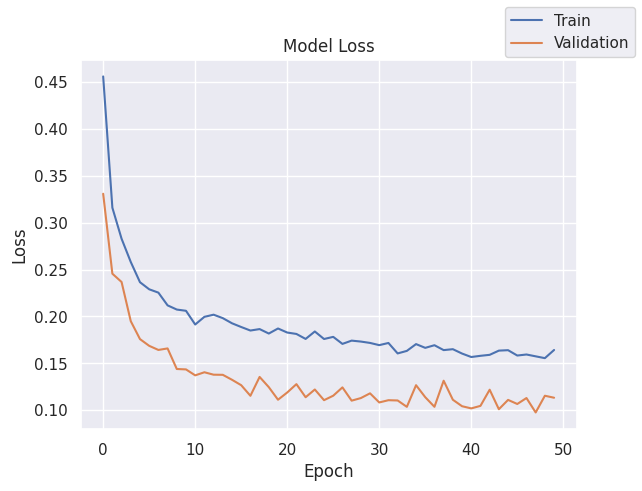

In [115]:
plot(history6,'loss')

In [124]:
evaluation_results.loc[6] = ['Model 6', '3', '[28, 14, 14]', 'ReLU', 'Class Weights,Optimizer=Adam,Dropout(0.1)', epochs, batch_size, history6.history["loss"][-1], history6.history["binary_accuracy"][-1], history6.history["precision_1"][-1], history6.history["recall_1"][-1], 2 * (history6.history["precision_1"][-1] * history6.history["recall_1"][-1]) / (history6.history["precision_1"][-1] + history6.history["recall_1"][-1] + 1e-7), history6.history["val_loss"][-1], history6.history["val_binary_accuracy"][-1], history6.history["val_precision_1"][-1], history6.history["val_recall_1"][-1], 2 * (history6.history["val_precision_1"][-1] * history6.history["val_recall_1"][-1]) / (history6.history["val_precision_1"][-1] + history6.history["val_recall_1"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[14],ReLU,baseline,50,64,0.067027,0.985187,0.973799,0.753378,0.849524,0.066507,0.98475,0.976331,0.743243,0.843990
1,Model 1,3,"[28, 14,14]",ReLU,momentum=0.9,50,64,0.030518,0.993875,0.988861,0.899775,0.942217,0.048436,0.99150,0.943396,0.900901,0.921659
2,Model 2,3,"[28, 14, 14]",ReLU,"momentum=0.9,Dropout(0.2)",50,64,0.055385,0.988625,0.969415,0.820946,0.889024,0.036342,0.99350,0.971154,0.909910,0.939535
3,Model 3,3,"[28, 14, 14]",ReLU,"optimizer=adam,momentum=0.9,Dropout(0.2)",50,64,0.047309,0.991562,0.977186,0.868243,0.919499,0.035026,0.99375,0.975845,0.909910,0.941725
4,Model 4,3,"[28, 14,14]",ReLU,"BatchNormalization(),momentum=0.9 ,Dropout(0.2)",50,64,0.062774,0.984750,0.937500,0.777027,0.849754,0.040826,0.99175,0.994764,0.855856,0.920097
5,Model 5,3,"[28, 14,14]",ReLU,"Class Weights,momentum=0.9,Dropout(0.2)",50,64,0.184231,0.981250,0.792829,0.896396,0.841438,0.122841,0.98650,0.850000,0.918919,0.883117
6,Model 6,3,"[28, 14, 14]",ReLU,"Class Weights,Optimizer=Adam,Dropout(0.1)",50,64,0.164196,0.978188,0.749768,0.911036,0.822572,0.113254,0.98450,0.822581,0.918919,0.868085


The validation recall score is same as  model 5,that means combined reducing dropout and adding class weights and Adam optimizer doesnt help to improve the performance

 But the training and validation loss slightly improved compared to model 5 indicating slightly better convergence and more stable learning.

# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

###Model Performance Comparison and Final Model Selection

In [125]:
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[14],ReLU,baseline,50,64,0.067027,0.985187,0.973799,0.753378,0.849524,0.066507,0.98475,0.976331,0.743243,0.843990
1,Model 1,3,"[28, 14,14]",ReLU,momentum=0.9,50,64,0.030518,0.993875,0.988861,0.899775,0.942217,0.048436,0.99150,0.943396,0.900901,0.921659
2,Model 2,3,"[28, 14, 14]",ReLU,"momentum=0.9,Dropout(0.2)",50,64,0.055385,0.988625,0.969415,0.820946,0.889024,0.036342,0.99350,0.971154,0.909910,0.939535
3,Model 3,3,"[28, 14, 14]",ReLU,"optimizer=adam,momentum=0.9,Dropout(0.2)",50,64,0.047309,0.991562,0.977186,0.868243,0.919499,0.035026,0.99375,0.975845,0.909910,0.941725
4,Model 4,3,"[28, 14,14]",ReLU,"BatchNormalization(),momentum=0.9 ,Dropout(0.2)",50,64,0.062774,0.984750,0.937500,0.777027,0.849754,0.040826,0.99175,0.994764,0.855856,0.920097
5,Model 5,3,"[28, 14,14]",ReLU,"Class Weights,momentum=0.9,Dropout(0.2)",50,64,0.184231,0.981250,0.792829,0.896396,0.841438,0.122841,0.98650,0.850000,0.918919,0.883117
6,Model 6,3,"[28, 14, 14]",ReLU,"Class Weights,Optimizer=Adam,Dropout(0.1)",50,64,0.164196,0.978188,0.749768,0.911036,0.822572,0.113254,0.98450,0.822581,0.918919,0.868085


**Model0**-This is the base model with a low validation recall and high accuracy,indicating that it fails to identify false negatives(actual failures)

**Model1**-Adding additional layers and momentum  helped to improve the recall score significantly.Both training and validation loss decreased compared to baseline model

**Model2**-Validation recall improved marginally when we added the dropout.The model performance is more stable on unseen validation data.

**Model3**-Changing the optimizer to Adam doent help the model to improve the performance compared to Model 2.Replacing SGD with Adam improved convergence and reduced validation loss.

**Model4**-The recall value for the validation dataset decreased due to batch normalization.But it helped to stabilized the training performance.

**Model5**-Applying class weights significantly improved validation recall,making the model better at identifying failure cases.This model achieved the best balance between recall and precision for the imbalanced dataset

**Model6**-Reducing dropout and using the Adam resulted slightly lower validation loss.However validation recall remained almost same as Model 5 .So these additional modifications did not provide any significant performance improvement over model 5.

###Final Model

Model 5 is selected as the final modelbecause it achieved the best validation recall while mainitaining reasonable precision.Since the primary business objective is to identify the failure machine recall is priorized over overall accuracy.

Now, let's check the performance of the final model on the test set.

In [119]:
y_test_pred = model5.predict(X_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [120]:
print("Classification Report - Test data",end="\n\n")
cr = classification_report(y_test,y_test_pred>0.5)
print(cr)

Classification Report - Test data

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4718
           1       0.84      0.87      0.86       282

    accuracy                           0.98      5000
   macro avg       0.92      0.93      0.92      5000
weighted avg       0.98      0.98      0.98      5000



We got the overall recall of 87% for the minority class on test data with a precision of 84% .This model achieved an overall accuracy of 98%.This indicates that the model is effectively identifying the failure machines.

# **Actionable Insights and Recommendations**



Since machine failure cost is higher than inspection cost, recall is prioritized to reduce missed failure cases.

The final model achieved strong recall performance and can effectively identify potential machine failures in advance.

 Applying class weights improved the model performance on the imbalanced dataset, while changing the optimizer did not significantly improve recall.


